In [1]:
import logging
import os

In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
import galsim
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from chromatic_weak_lensing import utils
from chromatic_weak_lensing.diffsky import Diffsky
from chromatic_weak_lensing.roman_rubin import RomanRubin

I0000 00:00:1746480424.429642  161728 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
INFO:jax._src.xla_bridge:Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [5]:
bands = {"u", "g", "r", "i", "z", "y"}
bandpasses = {
    band: galsim.Bandpass(f"LSST_{band}.dat", "nm").withZeropoint("AB")
    for band in bands
}

In [6]:
# ! curl https://portal.nersc.gov/project/hacc/aphearin/lsstdesc_diffsky_data/roman_rubin_2023_z_0_1_cutout_9043.testdata.hdf5 > diffsky.testdata.hdf5

In [7]:
# input data is structured like a dictionary (columnar access)
data = {}

fn = "diffsky.testdata.hdf5"
with h5py.File(fn) as hf:
    for key in hf.keys():
        if key != "metaData":
            snap = hf[key]
            for field in snap.keys():
                if field not in data:
                    data[field] = np.array([])
                data[field] = np.append(data[field], snap[field][:])
        else:
            for k, v in hf[key].items():
                print(f"{k}: {v[()]}")

H_0: 71.0
Omega_b: 0.0448
Omega_matter: 0.2648
commit_hash: b'7269934'
diffmah: b'0.4.2'
diffstar: b'0.2.2'
dsps: b'0.3.5'
healpix_cutout_number: 9043
lsstdesc_diffsky: b'0.1.6.dev51+g508b943.d20231024'
seed: 1507019545
skyArea: 3.357174580844667
versionMajor: 1
versionMinor: 0
versionMinorMinor: 0


In [8]:
# A hdf5 group will also work

# hf = h5py.File(fn)
# data = hf["247"]

In [9]:
# A pyarrow data source can also be used

# import pyarrow.dataset as ds

# dataset = ds.dataset("roman_rubin_2023_v1.1.3_parquet")
# data = dataset.head(100, columns=RomanRubin.columns, filter=(ds.field("LSST_obs_i") < 26))

In [10]:
roman_rubin = RomanRubin(data)
diffsky = Diffsky(red_limit=12_000)

INFO:chromatic_weak_lensing.diffsky.utils:reading diffsky population parameters for roman_rubin_2023
INFO:chromatic_weak_lensing.diffsky.utils:loading DSPS_SSP_DATA from /home/smau/Documents/software/chromatic-weak-lensing/src/chromatic_weak_lensing/diffsky/data/dsps_ssp_data_singlemet.h5
INFO:chromatic_weak_lensing.diffsky.diffsky:discarding 1241 of 5994 wavelengths from templates


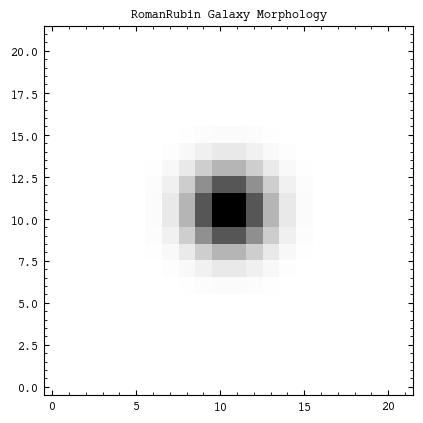

In [11]:
fig, axs = plt.subplots(1, 1)

axs.set_title("RomanRubin Galaxy Morphology")

i = 0

params = roman_rubin.get_morphology_params(i)
morph = diffsky.get_morphology(params)

psf = galsim.Gaussian(fwhm=0.7)
observed = galsim.Convolve([psf, morph])
image = observed.drawImage(scale=0.2)

axs.imshow(image.array, origin="lower")

plt.show()

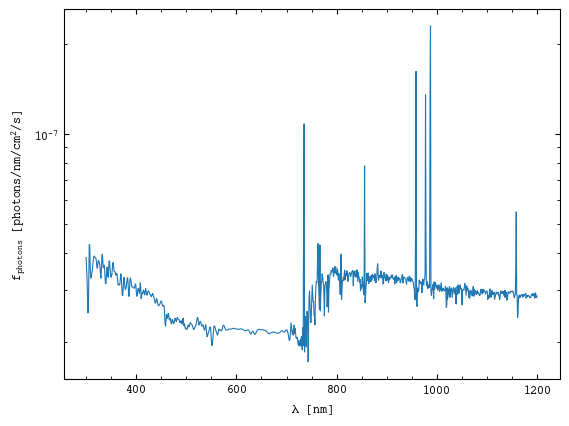

In [12]:
fig, axs = plt.subplots(1, 1)

axs.set_yscale("log")
axs.set_xlabel("$\lambda$ [$nm$]")
axs.set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")

wl = np.linspace(300, 1200, 1000)

i = 0
params = roman_rubin.get_spectrum_params(i)
spec = diffsky.get_spectrum(params)

axs.plot(wl, spec(wl))

plt.show()

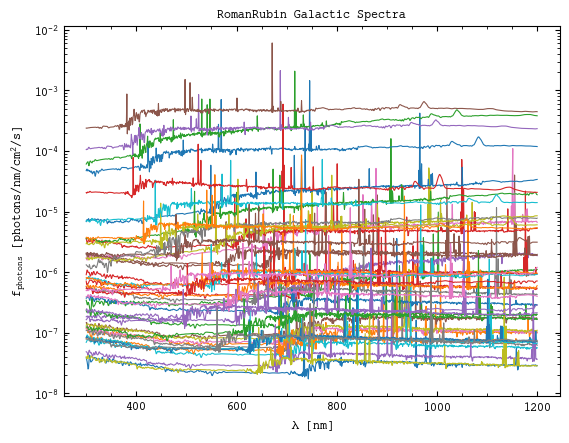

In [13]:
fig, axs = plt.subplots(1, 1)

axs.set_yscale("log")
axs.set_xlabel("$\lambda$ [$nm$]")
axs.set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")
axs.set_title("RomanRubin Galactic Spectra")

wl = np.linspace(300, 1200, 1000)

for i in range(roman_rubin.num_rows):
    params = roman_rubin.get_spectrum_params(i)
    spec = diffsky.get_spectrum(params)

    axs.plot(wl, spec(wl))

plt.show()

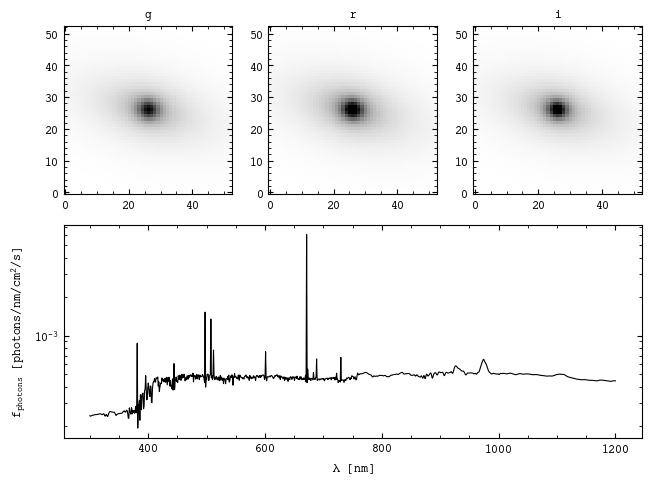

In [14]:
fig, axs = plt.subplot_mosaic(
    [
        ["g", "r", "i"],
        ["sed", "sed", "sed"]
    ],
    constrained_layout=True,
)

axs["sed"].set_yscale("log")
axs["sed"].set_xlabel("$\lambda$ [$nm$]")
axs["sed"].set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")

axs["g"].set_title("g")
axs["r"].set_title("r")
axs["i"].set_title("i")

# fig.suptitle("RomanRubin Galaxy")

wl = np.linspace(300, 1200, 1000)

i = -1

params = roman_rubin.get_params(i)
galaxy = diffsky.get_galaxy(params)

base_psf = galsim.Gaussian(fwhm=0.7)
psf = galsim.ChromaticAtmosphere(
    base_psf,
    700,
    alpha=-0.3,
    zenith_angle=0 * galsim.degrees,
    parallactic_angle=0 * galsim.degrees,
)

observed = galsim.Convolve([psf, galaxy])
g_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["g"])
r_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["r"])
i_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["i"])

norm = mpl.colors.Normalize()

axs["sed"].plot(wl, galaxy.sed(wl), c="k")
axs["g"].imshow(g_image.array, norm=norm, origin="lower")
axs["r"].imshow(r_image.array, norm=norm, origin="lower")
axs["i"].imshow(i_image.array, norm=norm, origin="lower")

plt.show()

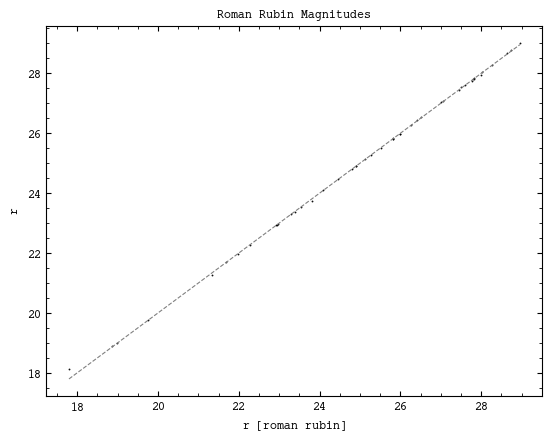

In [15]:
fig, axs = plt.subplots(1, 1)

axs.set_xlabel("$r$ [roman rubin]")
axs.set_ylabel("$r$")
axs.set_title("Roman Rubin Magnitudes")

roman_rubin_magnitudes = []
diffsky_magnitudes = []
for i in range(roman_rubin.num_rows):
    roman_rubin_magnitude = roman_rubin.data["LSST_obs_r"][i]
    roman_rubin_magnitudes.append(roman_rubin_magnitude)
    
    params = roman_rubin.get_spectrum_params(i)
    spec = diffsky.get_spectrum(params)
    diffsky_magnitude = spec.calculateMagnitude(bandpasses["r"])
    diffsky_magnitudes.append(diffsky_magnitude)

axs.plot(
    [np.min(roman_rubin_magnitudes), np.max(roman_rubin_magnitudes)],
    [np.min(roman_rubin_magnitudes), np.max(roman_rubin_magnitudes)],
    c="gray",
    ls="--",
)
axs.scatter(roman_rubin_magnitudes, diffsky_magnitudes, c="k")

plt.show()

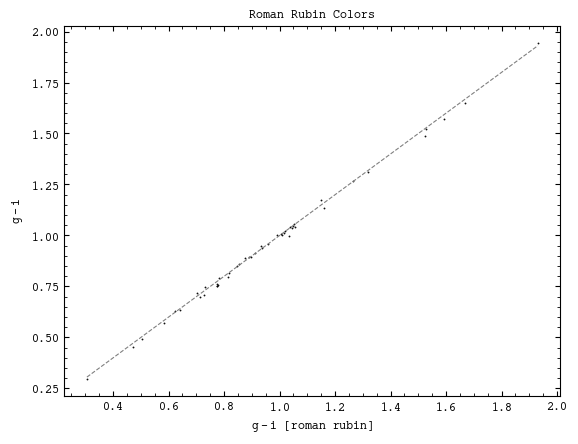

In [16]:
fig, axs = plt.subplots(1, 1)

axs.set_xlabel("$g - i$ [roman rubin]")
axs.set_ylabel("$g - i$")
axs.set_title("Roman Rubin Colors")

roman_rubin_colors = []
diffsky_colors = []
for i in range(roman_rubin.num_rows):
    roman_rubin_color = roman_rubin.data["LSST_obs_g"][i] - roman_rubin.data["LSST_obs_i"][i]
    roman_rubin_colors.append(roman_rubin_color)
    
    params = roman_rubin.get_spectrum_params(i)
    spec = diffsky.get_spectrum(params)
    diffsky_color = spec.calculateMagnitude(bandpasses["g"]) - spec.calculateMagnitude(bandpasses["i"])
    diffsky_colors.append(diffsky_color)

axs.plot(
    [np.min(roman_rubin_colors), np.max(roman_rubin_colors)],
    [np.min(roman_rubin_colors), np.max(roman_rubin_colors)],
    c="gray",
    ls="--",
)
axs.scatter(roman_rubin_colors, diffsky_colors, c="k")

plt.show()

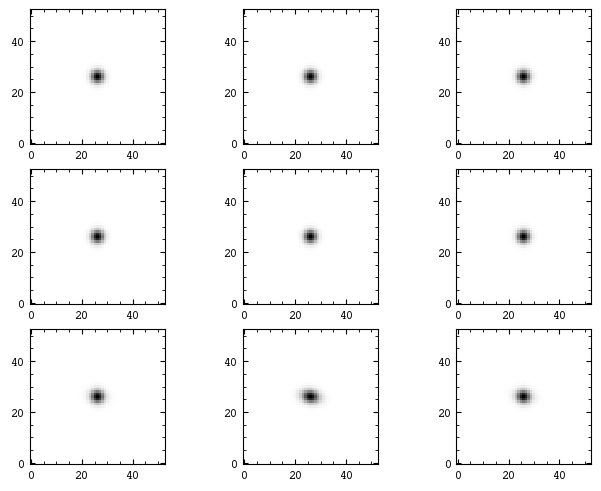

In [17]:
num_gal = min(3, roman_rubin.num_rows)

fig, axs = plt.subplots(num_gal, 3, constrained_layout=True)

for j in range(num_gal):
    params = roman_rubin.get_params(j)
    galaxy = diffsky.get_galaxy(params)
    for i, obj in enumerate(galaxy.obj_list):
        observed = galsim.Convolve([psf, obj])
        image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["g"])
        axs[j, i].imshow(image.array, origin="lower")

    observed = galsim.Convolve([psf, galaxy])
    image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["g"])
    axs[j, -1].imshow(image.array, origin="lower")

plt.show()